In [1]:
import pandas as pd
import numpy as np



## Loja controles datos

Una sola base de datos para unir con la otra base. 
Aqui falta trabajar los IDs creo que estan solo los IDs nuevos, pero eso hay que revisar bien para ver las coincidencias

In [2]:
### config, encontrar una manera que sea un solo documento
named13C_cellulose = "δ13C (‰ v.s.V-PDB)"
named13C_bulk = "bulk_δ13C (‰ v.s.V-PDB)"
name18O = "δ18O in ‰ vs DeltaSMOW"
named15N = "δ15N (‰ v.s. V-PDB)"
nameC_bulk ="[C_b]%"
nameC_cellulose = "[C]%"
thick = "mean_thickness_(mm)"
though = "mean_toughness_(kN/m)"
LA = "Leaf area (cm²)"
name = "genus" + "especie"
ID = "Sample-ID"

In [3]:
rasgos_2024 = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\SF_CONTROL\data_for_R.xlsx")
#cambiar nombres de columnas para que quede bien 
rasgos_2024_controles = rasgos_2024[rasgos_2024["Sub"]=="C"]
rasgos_2024_controles["Year"] = 2024

rasgos_2024_controles.sort_values(by="Plot")### Solo 2024.
#en rasgos solo mantener las columnas de los rasgos. 

C:\Users\selene.baez\AppData\Local\Temp\ipykernel_19048\20011820.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rasgos_2024_controles["Year"] = 2024


,Unnamed: 0,Plot,TreeID,Sub,name,genus,specie,Site,[C_b],bulk_δ13C (‰ v.s.V-PDB),...,LNC,LPC,N_area,C_area,P_area,C:P,N:P,N,P,Year
0,0,1,1608,C,Weinmania loxensis,Weinmania,loxensis,CaNu,0.448019,-29.445403,...,11.318031,0.586049,1.583412,62.678630,0.081989,764.474297,19.312442,0,0,2024
170,170,1,92,C,Alchornea lojaensis,NaN,Alchornea lojaensis,SFNu,0.498364,-28.200675,...,11.501315,0.732131,3.580329,155.139517,0.227911,680.703451,15.709357,0,0,2024
150,150,1,90,C,Myrcia sp nov,NaN,Myrcia sp nov,SFNu,0.487816,-30.854881,...,8.778926,0.324985,2.545161,141.426115,0.094219,1501.042394,27.013355,0,0,2024
147,147,1,96,C,Myrcia sp nov,NaN,Myrcia sp nov,SFNu,0.467702,-33.285472,...,10.396620,0.360224,2.277284,102.445748,0.078904,1298.365099,28.861575,0,0,2024
142,142,1,5812,C,Myrcia sp nov,NaN,Myrcia sp nov,SFNu,0.474813,-30.184038,...,9.051801,0.330146,2.808968,147.344794,0.102451,1438.191984,27.417563,0,0,2024
117,117,1,69,C,Alchornea lojaensis,NaN,Alchornea lojaensis,SFNu,0.493337,-29.756254,...,12.771393,0.733031,3.326850,128.510592,0.190949,673.010484,17.422729,0,0,2024
174,174,1,101,C,Alchornea lojaensis,NaN,Alchornea lojaensis,SFNu,0.491481,-29.736809,...,13.114366,0.788999,3.145972,117.900075,0.189271,622.916971,16.621526,0,0,2024
87,87,1,88,C,Myrcia sp nov,NaN,Myrcia sp nov,SFNu,0.461137,-30.893770,...,7.764933,0.302269,2.273111,134.993606,0.088486,1525.586490,25.688825,0,0,2024
58,58,1,19003,C,Hedyosmun purpurascens,Hedyosmun,purpurascens,CaNu,0.432270,-30.631127,...,15.349907,0.905815,1.640719,46.204400,0.096821,477.216224,16.945955,0,0,2024
89,89,1,9096,C,Myrcia sp nov,NaN,Myrcia sp nov,SFNu,0.470921,-31.778506,...,10.423766,0.362506,2.747689,124.133947,0.095556,1299.069369,28.754737,0,0,2024


# Muestras de 2009 controles.

In [4]:
#old tree ID = treeID
#new tree ID = TreeID
#
samples_SF = pd.read_excel("SanFranciscoNumex2011.xlsx")
samples_SF = samples_SF.rename(columns = {"sample":"sample ID","site":"Site","tree#":"tree ID"})
samples_SF["Year"]= "2011"
samples_SF["sample ID"] = "46"+samples_SF["sample ID"].astype("str") #46 al inicio de todas
samples_SF["sample ID"] = samples_SF["sample ID"].replace({"4694":"46094","4697":"46097","4693":"46093"})
samples_SF["Site"] = "SFNu"
samples_CaNU_BoNU = pd.read_excel("Samples_NUMEX2009.xlsx")
samples_CaNU_BoNU["Year"] = "2009"
samples_CaNU_BoNU = samples_CaNU_BoNU.rename(columns={"Site ":"Site"}) #elimina el espacio presente
samples_2009 = pd.concat([samples_SF,samples_CaNU_BoNU])
samples_2009

,sample ID,Site,plot,treatment,tree ID,species,Bezeichnung,Year
0,46094,SFNu,1,C,69,Alchornea lojaensis,SF-C1-69-2011,2011
1,46097,SFNu,1,C,109,Alchornea lojaensis,SF-C1-109-2011,2011
2,46142,SFNu,7,C,334,Alchornea lojaensis,SF-C7-334-2011,2011
3,46143,SFNu,7,C,335,Alchornea lojaensis,SF-C7-335-2011,2011
4,46186,SFNu,12,C,713,Alchornea lojaensis,SF-C12-713-2011,2011
5,46189,SFNu,12,C,714,Alchornea lojaensis,SF-C12-714-2011,2011
6,46229,SFNu,17,C,881,Alchornea lojaensis,SF-C17-881-2011,2011
7,46237,SFNu,17,C,882,Alchornea lojaensis,SF-C17-882-2011,2011
8,46093,SFNu,1,C,68,Myrcia sp.,SF-C1-68-2011,2011
9,46144,SFNu,7,C,341,Myrcia sp.,SF-C7-341-2011,2011


# Celulosa 2006

In [5]:
#CELLULOSA
celulosa = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\Andrea-Cellulose-13C-202603.xlsx") #TODAVIA NO ME DAN LOS RESULTADOS
samples_list_CaBo = ["p09-0157","p09-0163","p09-0132","p09-0188","p09-183",
                     "p04-175","p09-0164","pxx-0124","p09-01343", "p09-0109",
                    "p09-0122","p09-0130","p09-139", "p09-151", "p09-131", 
                    "p09-120", "p09-138","p09-0128","p04-0129","p09-107",
                    "p09-168","p09-167","p09-176", ######muestras del 2011
                    46229, 46097,46143,46093,46185,46144,46237,46145,46232,46142,46094,"46186","46152"
                    ] #meti la pata en los nombres y les puse p09.

cel2026 = celulosa[celulosa["Sample-ID"].isin(samples_list_CaBo)]

cel2026["Sample-ID"] = cel2026["Sample-ID"].replace({
    "p09-0157":"2009-0157",
    "p09-0163":"2009-0163",
    "p09-0132":"2009-0132",
    "p09-0188":"2009-0188",
    "p09-183":"2009-0183",
    "p04-175":"2009-0175",
    "p09-0164":"2009-0164",
    "pxx-0124":"2009-0129", #### 0124 no existe.
    #"p09-01343", 
    "p09-0109":"2009-0109",
    "p09-0122":"2009-0122",
    "p09-0130":"2009-0130",
    "p09-139":"2009-0139",
    "p09-151":"2009-0151",
    "p09-131":"2009-0131",
    "p09-120": "2009-0120", "p09-138":"2009-0138",
    "p09-0128":"2009-0128","p04-0129":"2009-0129","p09-107":"2009-0107",
    "p09-168":"2009-0168","p09-167":"2009-0167","p09-176":"2009-0176"
})

cel2026["Sample-ID"] = cel2026["Sample-ID"].astype(str)
## 121 no hay, 

#HELP: Fijarse que hay unos tipos y tener cuidado de no mezclar con Sumaco. "PQ1"
#Luego unir resultados con la lista de arriba. Corregir los typos. 
cel2026ctrl = pd.merge(samples_2009,cel2026, left_on="sample ID",right_on= "Sample-ID", how="outer")
cel2026ctrl["sample ID"] = cel2026ctrl["sample ID"].combine_first(cel2026ctrl["Sample-ID"])
cel2026ctrl = cel2026ctrl.drop(columns=["treatment","nr of samples","Bezeichnung","Sample-ID"])

cel2026ctrl = cel2026ctrl.rename(columns={"[C] m/m in %":nameC_cellulose,"plot":"Plot","sample ID":ID,"tree ID":"old_treeID"
                                  })

cel2026ctrl
#hay unas muestras p09-183, y p09-0140 que tal vez son controles en NUMEX.SF

C:\Users\selene.baez\AppData\Local\Temp\ipykernel_19048\231325423.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cel2026["Sample-ID"] = cel2026["Sample-ID"].replace({
C:\Users\selene.baez\AppData\Local\Temp\ipykernel_19048\231325423.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cel2026["Sample-ID"] = cel2026["Sample-ID"].astype(str)


,Sample-ID,Site,Plot,old_treeID,species,Year,[C]%,δ13C (‰ v.s. V-PDB),Batch
0,46094,SFNu,1.0,69.0,Alchornea lojaensis,2011,51.020000,-26.960000,AndreaChavez-Sumaco-SEQ3-HF1-C - repro
1,46097,SFNu,1.0,109.0,Alchornea lojaensis,2011,49.738208,-25.990777,AndreaChavez-Sumaco-SEQ2-HF1-C - repro
2,46142,SFNu,7.0,334.0,Alchornea lojaensis,2011,48.805481,-26.141274,AndreaChavez-Sumaco-SEQ2-HF1-C - repro
3,46143,SFNu,7.0,335.0,Alchornea lojaensis,2011,49.398647,-27.058350,AndreaChavez-Sumaco-SEQ2-HF1-C - repro
4,46186,SFNu,12.0,713.0,Alchornea lojaensis,2011,48.355538,-24.989506,AndreaChavez-Sumaco-SEQ2-HF1-C - repro
5,46189,SFNu,12.0,714.0,Alchornea lojaensis,2011,NaN,NaN,NaN
6,46229,SFNu,17.0,881.0,Alchornea lojaensis,2011,45.680476,-25.804918,AndreaChavez-Sumaco-SEQ2-HF1-C - repro
7,46237,SFNu,17.0,882.0,Alchornea lojaensis,2011,48.166891,-27.686740,AndreaChavez-Sumaco-SEQ2-HF1-C - repro
8,46093,SFNu,1.0,68.0,Myrcia sp.,2011,43.501389,-28.270380,AndreaChavez-Sumaco-SEQ2-HF1-C - repro
9,46144,SFNu,7.0,341.0,Myrcia sp.,2011,44.155086,-26.660377,AndreaChavez-Sumaco-SEQ2-HF1-C - repro


# Nutrientes: C, N, delta15N. Faltan los controles de SF del 2009

In [6]:

#SEQ1= pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\Andrea_bulk CN_2025.xlsx",sheet_name="SEQ1")
#SEQ1["Year"] = 2006

SEQ7 = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\Andrea_bulk CN_2025.xlsx",sheet_name="SEQ7")
SEQ7["Year"] = 2009 #segun yo es la unica secuencia util con resultados de isotopos de controles

bulk = SEQ7
bulk
bulk = bulk.rename(columns={"certified values":"sample-ID", "Unnamed: 2":"[N]",
                         "Unnamed: 4":nameC_bulk,"Unnamed: 6":named15N,
                          "Unnamed: 8":named13C_bulk})

columns_drop = ["Unnamed: 0", "Unnamed: 3","Unnamed: 5","Unnamed: 7", "Unnamed: 9"]

bulk = bulk.drop(columns=columns_drop)
bulk

patrones = ["p09"]# Seleccionamos solo los controles de 2009
df_filtrado_bulk = bulk[bulk["sample-ID"].str.contains("|".join(patrones), na=False)]
df_filtrado_bulk[["Plot2009","code","Year"]] =df_filtrado_bulk["sample-ID"].str.split("-",expand=True)
df_filtrado_bulk["sample-ID"] = "2009-" + df_filtrado_bulk["code"] ##reemplazamos ID por nombre correcto
df_filtrado_bulk = df_filtrado_bulk.drop(columns = {"Plot2009","Year","code"}) # el año igual lo añadimos despues
df_filtrado_bulk

## añadir informacion
df_filtrado_bulk_info = pd.merge(df_filtrado_bulk,samples_CaNU_BoNU, left_on="sample-ID",right_on="sample ID")


C:\Users\selene.baez\AppData\Local\Temp\ipykernel_19048\3070521295.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado_bulk[["Plot2009","code","Year"]] =df_filtrado_bulk["sample-ID"].str.split("-",expand=True)
C:\Users\selene.baez\AppData\Local\Temp\ipykernel_19048\3070521295.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado_bulk[["Plot2009","code","Year"]] =df_filtrado_bulk["sample-ID"].str.split("-",expand=True)
C:\Users\selene.baez\AppData\Local\Temp\ipykernel_19048\3070521295

# NEXT: 
1. Concatenar entre 2009 y 2025.

In [7]:
df1= rasgos_2024_controles
df2= df_filtrado_bulk_info

df2_no_coinciden = df2[~df2["tree ID"].isin(df1["TreeID"])]
df2_no_coinciden ### Buscar que paso con estas. Tal vez se perdieron o hay  nuevos IDs. 

,sample-ID,[N],[C_b]%,δ15N (‰ v.s. V-PDB),bulk_δ13C (‰ v.s.V-PDB),sample ID,plot,treatment,tree ID,species,Site,Year
4,2009-0122,0.016736,0.472505,1.072349,-32.196189,2009-0122,4,C,2062,Pouteria torta,BoNu,2009
7,2009-0130,0.017966,0.462576,0.678115,-33.288261,2009-0130,8,C,1931,Pouteria torta,BoNu,2009
9,2009-0132,0.016301,0.46505,1.021807,-34.751226,2009-0132,8,C,1949,Pouteria torta,BoNu,2009
10,2009-0138,0.015146,0.469643,1.052132,-32.711317,2009-0138,12,C,2162,Pouteria torta,BoNu,2009
11,2009-0139,0.014501,0.476541,0.668006,-32.464055,2009-0139,12,C,2164,Pouteria torta,BoNu,2009
12,2009-0140,0.015254,0.472274,0.384965,-32.484661,2009-0140,12,C,2173,Pouteria torta,BoNu,2009
13,2009-0151,0.013667,0.443061,-2.020879,-26.931576,2009-0151,5,C,26,Hedyosmum sp.,CaNu,2009
14,2009-0157,0.013989,0.4401,-3.850533,-27.889715,2009-0157,10,C,12,Hedyosmum sp.,CaNu,2009
15,2009-0163,0.013879,0.437443,-1.050454,-30.187188,2009-0163,14,C,22,Hedyosmum sp.,CaNu,2009
16,2009-0164,0.013718,0.394436,-1.677187,-28.384238,2009-0164,14,C,23,Hedyosmum sp.,CaNu,2009


In [8]:
df_filtrado_bulk_info["tree ID"] = df_filtrado_bulk_info["tree ID"].replace({
    1931: 7546,
    2162: 7626,
    2164: 7587,  # muerto
    2173: 6007,
    26: 19006,
    12: 19011,
    22: 19017,  
    23: 19018,  
    1602: 5861,
    1243: 5819
})

df_filtrado_bulk_info =df_filtrado_bulk_info.rename(columns={"plot":"Plot","δ13C (‰ v.s. V-PDB)":named13C_cellulose,"sample-ID":ID})
df_filtrado_bulk_info = df_filtrado_bulk_info.drop(columns=["Plot","species","tree ID","sample ID","Year","Site"])# para evitar x y y


ctrl = pd.merge(df_filtrado_bulk_info,cel2026ctrl, on= ID ,how="outer")
ctrl = ctrl.rename(columns={"δ13C (‰ v.s. V-PDB)":named13C_cellulose,"species":"name","tree ID":"TreeID",
                            "[C]%":nameC_cellulose,"δ15N (‰ v.s. V-PDB)":named15N,"treatment":"Sub"})
ctrl["Year"]=2009

In [9]:
rasgos_2024_controles = rasgos_2024_controles.rename(columns={"[C_b]":nameC_bulk,"δ15N (‰ v.s.AIR)":named15N,"[C]":nameC_cellulose})

In [10]:
### Homogeneizar columnas para unir.


In [11]:
df = pd.concat([rasgos_2024_controles,ctrl])
df['Site'] = df['Site'].replace('BoN', 'BoNu')
df['Site'] = df['Site'].replace("CaNu ","CaNu")


In [12]:
import calculate_iWUE_SF
%run calculate_iWUE_SF

In [13]:
df_wue = df.apply(calculate_iWUE, axis=1)


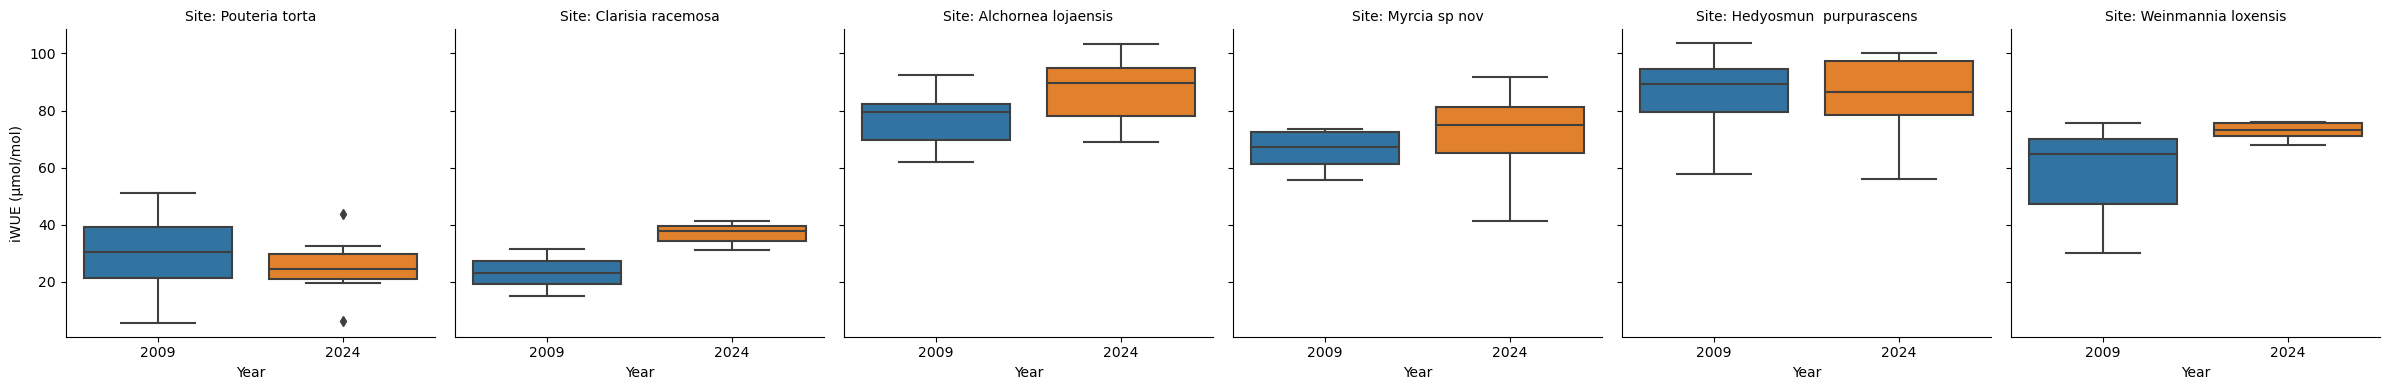

In [14]:
iWUE= "iWUE (μmol/mol)"

import seaborn as sns

# definir orden de los sitios
site_order = ["BoNu", "SFNu", "CaNu"]
name_order = ["Pouteria torta","Clarisia racemosa","Alchornea lojaensis","Myrcia sp nov","Hedyosmun  purpurascens","Weinmannia loxensis"]
# convertir a categoría ordenada
df_wue["Site"] = pd.Categorical(df_wue["Site"], categories=site_order, ordered=True)

iWUE = "iWUE (μmol/mol)"

df_wue["name"] = df["name"].replace({
    "Weinmania  loxensis": "Weinmannia loxensis",
    "Hedyosmum sp.": "Hedyosmun  purpurascens",
    "Clarisia  racemosa":"Clarisia racemosa",
    "Myrcia sp.":"Myrcia sp nov"
})
g = sns.catplot(
    data=df_wue,
    x='Year',
    y="iWUE (μmol/mol)",
    col='name',
    col_order=name_order,   # 👈 importante para facets
    kind='box',
    height=4,
    aspect=1
)

g.set_axis_labels("Year", "iWUE (μmol/mol)")
g.set_titles("Site: {col_name}")

import matplotlib.pyplot as plt
plt.show()

In [15]:
df_wue.to_excel("iWUE_SF.xlsx")